# Hybrid NN-Circuit for CartPole

In [2]:
import equinox as eqx
import gymnax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from torx import (
    DiscretePCircuit,
    draw_circuit,
    PNOT,
    PReset,
    PSWAP,
    StateVectorSimulator,
)

In [3]:
NUM_ENVS = 64
TOTAL_TIMESTEPS = 500_000
LEARNING_RATE = 3e-3
BUFFER_SIZE = 10_000
GAMMA = 0.99
BATCH_SIZE = 128
EPS_START = 1.0
EPS_END = 0.01
EPS_FRACTION = 0.3
LEARNING_STARTS = 1_000
HIDDEN_DIM = 64
NUM_SAMPLES = 1000
NUM_SEEDS = 5

In [4]:
NUM_QUBITS = 2
NUM_GATES = 6


class HybridDQN(eqx.Module):
    linear1: eqx.nn.Linear
    ln1: eqx.nn.LayerNorm
    linear_theta: eqx.nn.Linear
    circuit_template: DiscretePCircuit
    sim: StateVectorSimulator = eqx.field(static=True)

    def __init__(
        self,
        obs_dim: int,
        hidden_dim: int,
        key,
    ):
        k1, k2 = jax.random.split(key, 2)
        self.linear1 = eqx.nn.Linear(obs_dim, hidden_dim, key=k1)
        self.ln1 = eqx.nn.LayerNorm(hidden_dim)
        self.linear_theta = eqx.nn.Linear(hidden_dim, NUM_GATES, key=k2)
        self.sim = StateVectorSimulator()
        self.circuit_template = DiscretePCircuit(
            [
                PNOT(jnp.array(0.0), sites=0),
                PNOT(jnp.array(0.0), sites=1),
                PSWAP(jnp.array(0.0), sites=[0, 1]),
                PReset(jnp.array(0.0), sites=0),
                PReset(jnp.array(0.0), sites=1),
                PSWAP(jnp.array(0.0), sites=[0, 1]),
            ]
        )

    def get_thetas(self, obs):
        x = jax.nn.relu(self.ln1(self.linear1(obs)))
        return 2 * jnp.tanh(self.linear_theta(x))

    def __call__(self, obs):
        thetas = self.get_thetas(obs)

        gates = list(self.circuit_template.gates)
        new_gates = []
        for i, gate in enumerate(gates):
            new_gates.append(eqx.tree_at(lambda g: g.theta, gate, thetas[i]))
        circuit = DiscretePCircuit(new_gates)
        compiled = StateVectorSimulator.build_circuit(circuit)

        # |00) state vector
        init_state = jnp.zeros(2**NUM_QUBITS)
        init_state = init_state.at[0].set(1.0)

        expvals = self.sim.expval_all(compiled, init_state)
        return 20.0 * (2.0 * expvals - 1.0)

In [5]:
circuit = DiscretePCircuit(
    [
        PNOT(jnp.array(0.0), sites=0),
        PNOT(jnp.array(0.0), sites=1),
        PSWAP(jnp.array(0.0), sites=[0, 1]),
        PReset(jnp.array(0.0), sites=0),
        PReset(jnp.array(0.0), sites=1),
        PSWAP(jnp.array(0.0), sites=[0, 1]),
    ]
)
draw_circuit(circuit)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


     ┌──────┐┌───────┐┌────────┐┌───────┐  
p_0: ┤ PNOT ├┤ PSWAP ├┤ PReset ├┤ PSWAP ├──
     └──────┘│       │└────────┘│       │  
     ┌──────┐│       │┌────────┐│       │  
p_1: ┤ PNOT ├┤       ├┤ PReset ├┤       ├──
     └──────┘└───────┘└────────┘└───────┘  


In [6]:
class ReplayBuffer:
    def __init__(self, capacity, obs_dim):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int32)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0
        self.capacity = capacity

    def add_batch(self, obs, next_obs, actions, rewards, dones):
        n = len(obs)
        idx = np.arange(self.pos, self.pos + n) % self.capacity
        self.obs[idx] = np.asarray(obs)
        self.next_obs[idx] = np.asarray(next_obs)
        self.actions[idx] = np.asarray(actions)
        self.rewards[idx] = np.asarray(rewards)
        self.dones[idx] = np.asarray(dones)
        self.pos = (self.pos + n) % self.capacity
        self.size = min(self.size + n, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            jnp.array(self.obs[idx]),
            jnp.array(self.next_obs[idx]),
            jnp.array(self.actions[idx]),
            jnp.array(self.rewards[idx]),
            jnp.array(self.dones[idx]),
        )


def train(seed):
    key = jax.random.key(seed)
    env, env_params = gymnax.make("CartPole-v1")

    key, model_key = jax.random.split(key)
    q_net = HybridDQN(4, HIDDEN_DIM, model_key)
    optimizer = optax.adam(LEARNING_RATE)
    opt_state = optimizer.init(eqx.filter(q_net, eqx.is_inexact_array))

    key, env_key = jax.random.split(key)
    obs, env_states = jax.vmap(env.reset, in_axes=(0, None))(
        jax.random.split(env_key, NUM_ENVS), env_params
    )

    rb = ReplayBuffer(BUFFER_SIZE, 4)
    vmap_step = jax.jit(jax.vmap(env.step, in_axes=(0, 0, 0, None)))

    @eqx.filter_jit
    def get_q_values(model, obs):
        return eqx.filter_vmap(model)(obs)

    @eqx.filter_jit
    def do_train_step(q_net, opt_state, batch):
        obs, next_obs, actions, rewards, dones = batch

        def loss_fn(q_net):
            next_q = eqx.filter_vmap(q_net)(next_obs)
            next_max = jnp.max(next_q, axis=-1)
            td_target = jax.lax.stop_gradient(
                rewards + GAMMA * next_max * (1.0 - dones)
            )

            q_vals = eqx.filter_vmap(q_net)(obs)
            q_taken = q_vals[jnp.arange(BATCH_SIZE), actions]
            return jnp.mean((td_target - q_taken) ** 2)

        _, grads = eqx.filter_value_and_grad(loss_fn)(q_net)

        updates, new_opt = optimizer.update(
            grads, opt_state, eqx.filter(q_net, eqx.is_array)
        )
        new_q = eqx.apply_updates(q_net, updates)
        return new_q, new_opt

    ref_obs = jnp.zeros(4)
    ep_returns = np.zeros(NUM_ENVS)
    completed_returns = []
    theta_log = []
    eps_duration = int(TOTAL_TIMESTEPS * EPS_FRACTION)
    num_steps = TOTAL_TIMESTEPS // NUM_ENVS

    for step in range(num_steps):
        global_step = step * NUM_ENVS

        key, ek, sk = jax.random.split(key, 3)
        q_values = get_q_values(q_net, obs)
        epsilon = max(
            EPS_START + (EPS_END - EPS_START) * global_step / eps_duration,
            EPS_END,
        )
        greedy = jnp.argmax(q_values, axis=-1)
        random_a = jax.random.randint(ek, (NUM_ENVS,), 0, 2)
        explore = jax.random.uniform(ek, (NUM_ENVS,)) < epsilon
        actions = jnp.where(explore, random_a, greedy)

        step_keys = jax.random.split(sk, NUM_ENVS)
        next_obs, env_states, rewards, dones, _ = vmap_step(
            step_keys, env_states, actions, env_params
        )

        rb.add_batch(
            obs,
            next_obs,
            actions,
            rewards,
            dones.astype(jnp.float32),
        )

        ep_returns += np.array(rewards)
        for i in np.where(np.array(dones))[0]:
            completed_returns.append((global_step, ep_returns[i]))
            ep_returns[i] = 0.0

        obs = next_obs

        if global_step >= LEARNING_STARTS:
            batch = rb.sample(BATCH_SIZE)
            q_net, opt_state = do_train_step(q_net, opt_state, batch)

        if step % 10 == 0:
            thetas = q_net.get_thetas(ref_obs)
            theta_log.append((global_step, np.array(thetas)))

        if step % 2000 == 0 and completed_returns:
            recent = [r for _, r in completed_returns[-50:]]
            print(
                f"step {global_step}/{TOTAL_TIMESTEPS}  "
                f"ret={np.mean(recent):.0f}  eps={epsilon:.2f}"
            )

    return completed_returns, theta_log

In [7]:
all_results = []
all_theta_logs = []
for seed in range(10):
    results, theta_log = train(seed)
    all_results.append(results)
    all_theta_logs.append(theta_log)
    final_avg = np.mean([r for _, r in results[-50:]]) if results else 0
    print(f"Seed {seed}: {len(results)} episodes, final avg return {final_avg:.1f}")

step 128000/500000  ret=145  eps=0.16
step 256000/500000  ret=150  eps=0.01
step 384000/500000  ret=154  eps=0.01
Seed 0: 7814 episodes, final avg return 12.6
step 128000/500000  ret=93  eps=0.16
step 256000/500000  ret=26  eps=0.01
step 384000/500000  ret=213  eps=0.01
Seed 1: 5655 episodes, final avg return 183.7
step 128000/500000  ret=392  eps=0.16
step 256000/500000  ret=500  eps=0.01
step 384000/500000  ret=500  eps=0.01
Seed 2: 2983 episodes, final avg return 500.0
step 128000/500000  ret=470  eps=0.16
step 256000/500000  ret=500  eps=0.01
step 384000/500000  ret=364  eps=0.01
Seed 3: 3046 episodes, final avg return 242.1
step 128000/500000  ret=498  eps=0.16
step 256000/500000  ret=500  eps=0.01
step 384000/500000  ret=500  eps=0.01
Seed 4: 2949 episodes, final avg return 500.0
step 128000/500000  ret=208  eps=0.16
step 256000/500000  ret=203  eps=0.01
step 384000/500000  ret=211  eps=0.01
Seed 5: 3961 episodes, final avg return 204.6
step 128000/500000  ret=488  eps=0.16
step 

## Results

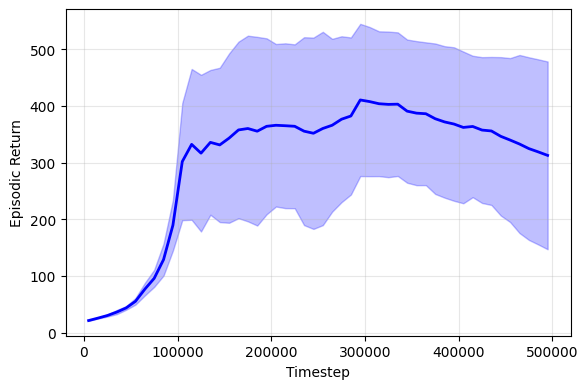

In [ ]:
def bin_returns(step_return_pairs, num_bins=50):
    steps = np.array([s for s, _ in step_return_pairs])
    returns = np.array([r for _, r in step_return_pairs])
    bin_edges = np.linspace(0, TOTAL_TIMESTEPS, num_bins + 1)
    centers, means = [], []
    for i in range(num_bins):
        mask = (steps >= bin_edges[i]) & (steps < bin_edges[i + 1])
        if mask.sum() > 0:
            means.append(returns[mask].mean())
        else:
            means.append(np.nan)
        centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
    return np.array(centers), np.array(means)


curves = []
for result in all_results:
    centers, means = bin_returns(result)
    curves.append(means)

curves = np.array(curves)
mean_curve = np.nanmean(curves, axis=0)
std_curve = np.nanstd(curves, axis=0)

plt.figure(figsize=(6, 4))
plt.plot(centers, mean_curve, color="blue", linewidth=2, label="Hybrid DQN")
plt.fill_between(
    centers,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.25,
    color="blue",
)
plt.xlabel("Timestep")
plt.ylabel("Episodic Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

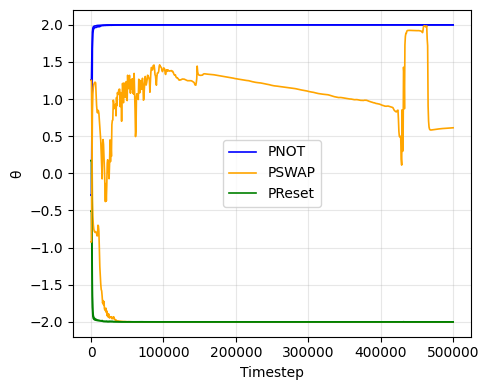

In [9]:
GATE_NAMES = [
    "PNOT(0)",
    "PNOT(1)",
    "PSWAP(0,1)",
    "PReset(0)",
    "PReset(1)",
    "PSWAP(0,1)",
]
GATE_COLORS = {
    "PNOT": "blue",
    "PSWAP": "orange",
    "PReset": "green",
}
GATE_TYPE = [name.split("(")[0] for name in GATE_NAMES]

fig, ax = plt.subplots(figsize=(5, 4))
theta_log = all_theta_logs[0]
steps = np.array([s for s, _ in theta_log])
thetas = np.array([t for _, t in theta_log])
labeled = set()
for g in range(NUM_GATES):
    gt = GATE_TYPE[g]
    label = gt if gt not in labeled else None
    labeled.add(gt)
    ax.plot(steps, thetas[:, g], linewidth=1.2, color=GATE_COLORS[gt], label=label)
ax.set_xlabel("Timestep")
ax.set_ylabel("θ")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()